**Dependency note:** this notebook needs kernel state from **`04_Astrocyte_Expansion`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 04.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/04_state.pkl")
print("Restored checkpoint: checkpoints/04_state.pkl")

In [ ]:
#Oligodendrocyte and Immune cell addition to the multipopulation tensor.

In [ ]:
# Check what columns are available
print("Somas dataframe columns:")
print(somas.columns.tolist())
print()

# Check oligodendrocyte and MG_OPC counts in spatial bounds of current patch
x_bounds = (patch['x'].min(), patch['x'].max())
y_bounds = (patch['y'].min(), patch['y'].max())
z_bounds = (patch['z'].min(), patch['z'].max())

oligo_patch = somas[
    (somas['celltype'] == 'OLIGO') &
    (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
    (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
    (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
]
mgopc_patch = somas[
    (somas['celltype'] == 'MG_OPC') &
    (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
    (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
    (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
]

print(f"OLIGO in current patch bounds:  {len(oligo_patch)}")
print(f"MG_OPC in current patch bounds: {len(mgopc_patch)}")
print()
print("OLIGO layer distribution:")
print(oligo_patch['layer'].value_counts())
print()
print("MG_OPC layer distribution:")
print(mgopc_patch['layer'].value_counts())
print()
print("Sample OLIGO row:")
print(oligo_patch.iloc[0])
print()
print("Somas columns:")
print(somas.columns.tolist())
print()

# Check for any morphology/skeleton variables in memory
for name, obj in list(globals().items()):
    if any(x in name.lower() for x in
           ['skel','morph','axon','whorl','segment','synapse','edge']):
        print(f"  Found: {name} — {type(obj).__name__}")

Somas dataframe columns:
['soma_id', 'base_seg_id', 'c2_rep_strict', 'c2_rep_manual', 'c3_rep_strict', 'c3_rep_manual', 'proofread_104_rep', 'x', 'y', 'z', 'celltype', 'layer']

OLIGO in current patch bounds:  1590
MG_OPC in current patch bounds: 933

OLIGO layer distribution:
layer
Layer 3    764
Layer 4    618
Layer 5    107
Layer 2     29
Layer 1     13
Name: count, dtype: int64

MG_OPC layer distribution:
layer
Layer 3    568
Layer 4    260
Layer 2     52
Layer 5     40
Layer 1      7
Name: count, dtype: int64

Sample OLIGO row:
soma_id                      36210
base_seg_id            91239444721
c2_rep_strict        64789003525.0
c2_rep_manual        64789003525.0
c3_rep_strict        82388552546.0
c3_rep_manual          82388552546
proofread_104_rep              NaN
x                           339630
y                           119116
z                             4608
celltype                     OLIGO
layer                      Layer 3
Name: 65, dtype: object

Somas columns:
[

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# OLIGODENDROCYTE + MG_OPC EXPANSION
# ============================================================
# OLIGO: myelination domain hyperedges
#   - Larger radius (25μm) — oligodendrocyte processes extend
#     further than astrocyte endfeet
#   - hyperedge = {oligo} + all neurons in myelination territory
#   - Biologically: neurons sharing oligodendrocyte myelination
#     have synchronized conduction velocity
#
# MG_OPC: immune surveillance hyperedges
#   - Standard radius (15μm) — microglial surveillance territory
#   - hyperedge = {mgopc} + all neurons being surveilled
#   - Biologically: neurons under shared microglial monitoring
#     are co-regulated for synaptic pruning
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from itertools import combinations
import scipy.sparse as sp

print("Loading OLIGO and MG_OPC from patch spatial bounds...")

x_bounds = (patch['x'].min(), patch['x'].max())
y_bounds = (patch['y'].min(), patch['y'].max())
z_bounds = (patch['z'].min(), patch['z'].max())

oligo_df = somas[
    (somas['celltype'] == 'OLIGO') &
    (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
    (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
    (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
].copy()

mgopc_df = somas[
    (somas['celltype'] == 'MG_OPC') &
    (somas['x'] >= x_bounds[0]) & (somas['x'] <= x_bounds[1]) &
    (somas['y'] >= y_bounds[0]) & (somas['y'] <= y_bounds[1]) &
    (somas['z'] >= z_bounds[0]) & (somas['z'] <= z_bounds[1])
].copy()

print(f"  OLIGO:  {len(oligo_df)} cells")
print(f"  MG_OPC: {len(mgopc_df)} cells")

# ── Spatial setup ─────────────────────────────────────────────
radius_myelin    = 25000   # 25μm — oligodendrocyte territory
radius_microglia = 15000   # 15μm — microglial surveillance

# All neurons (pyr + inter) as target nodes
all_neuron_coords = np.array([[patch.loc[n]['x'],
                                patch.loc[n]['y'],
                                patch.loc[n]['z']]
                               for n in all_nodes])
all_neuron_tree   = cKDTree(all_neuron_coords)
neuron_idx_map    = {n: i for i, n in enumerate(all_nodes)}

oligo_coords = oligo_df[['x','y','z']].values
mgopc_coords = mgopc_df[['x','y','z']].values

# ── Build OLIGO myelination hyperedges ────────────────────────
print(f"\nBuilding OLIGO myelination hyperedges (r=25μm)...")

oligo_hyperedges = {}
for oi, (oligo_id, orow) in enumerate(oligo_df.iterrows()):
    ocoord   = np.array([orow['x'], orow['y'], orow['z']])
    nearby   = all_neuron_tree.query_ball_point(ocoord,
                                                radius_myelin)
    if len(nearby) < 2:
        continue
    members  = [all_nodes[i] for i in nearby]
    oligo_hyperedges[oligo_id] = {
        'members': members,
        'size':    len(members),
        'layer':   orow.get('layer', 'unknown'),
        'coords':  ocoord
    }

oligo_sizes = [v['size'] for v in oligo_hyperedges.values()]
print(f"  Active OLIGO hyperedges: {len(oligo_hyperedges)}")
if oligo_sizes:
    print(f"  Mean domain size: {np.mean(oligo_sizes):.1f} neurons")
    print(f"  Max domain size:  {np.max(oligo_sizes)}")
    print(f"  Min domain size:  {np.min(oligo_sizes)}")

# ── Build MG_OPC surveillance hyperedges ──────────────────────
print(f"\nBuilding MG_OPC surveillance hyperedges (r=15μm)...")

mgopc_hyperedges = {}
for mi, (mg_id, mrow) in enumerate(mgopc_df.iterrows()):
    mcoord   = np.array([mrow['x'], mrow['y'], mrow['z']])
    nearby   = all_neuron_tree.query_ball_point(mcoord,
                                                radius_microglia)
    if len(nearby) < 2:
        continue
    members  = [all_nodes[i] for i in nearby]
    mgopc_hyperedges[mg_id] = {
        'members': members,
        'size':    len(members),
        'layer':   mrow.get('layer', 'unknown'),
        'coords':  mcoord
    }

mg_sizes = [v['size'] for v in mgopc_hyperedges.values()]
print(f"  Active MG_OPC hyperedges: {len(mgopc_hyperedges)}")
if mg_sizes:
    print(f"  Mean domain size: {np.mean(mg_sizes):.1f} neurons")
    print(f"  Max domain size:  {np.max(mg_sizes)}")
    print(f"  Min domain size:  {np.min(mg_sizes)}")

# ── Full 6-population summary ─────────────────────────────────
print(f"\n{'='*60}")
print(f"FULL 6-POPULATION HYPERGRAPH SUMMARY")
print(f"{'='*60}")
populations = {
    'Pyramidal broadcast':   len(hyperedges),
    'Integration':           len(integration_hyperedges),
    'Astrocyte modulator':   len(modulator_hyperedges),
    'Astrocyte hub':         len(hub_hyperedges),
    'OLIGO myelination':     len(oligo_hyperedges),
    'MG_OPC surveillance':   len(mgopc_hyperedges)
}
for name, count in populations.items():
    print(f"  {name:30s}: {count:,}")
print(f"\n  Total hyperedge types: 6")
print(f"  Cell populations:      5")
print(f"  (pyramidal, interneuron, astrocyte, oligo, MG_OPC)")

Loading OLIGO and MG_OPC from patch spatial bounds...
  OLIGO:  1590 cells
  MG_OPC: 933 cells

Building OLIGO myelination hyperedges (r=25μm)...
  Active OLIGO hyperedges: 1590
  Mean domain size: 130.5 neurons
  Max domain size:  200
  Min domain size:  27

Building MG_OPC surveillance hyperedges (r=15μm)...
  Active MG_OPC hyperedges: 933
  Mean domain size: 51.4 neurons
  Max domain size:  101
  Min domain size:  13

FULL 6-POPULATION HYPERGRAPH SUMMARY
  Pyramidal broadcast           : 1,766
  Integration                   : 852
  Astrocyte modulator           : 683
  Astrocyte hub                 : 683
  OLIGO myelination             : 1,590
  MG_OPC surveillance           : 933

  Total hyperedge types: 6
  Cell populations:      5
  (pyramidal, interneuron, astrocyte, oligo, MG_OPC)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# OLIGO + MG_OPC TENSOR COMPONENTS
# ============================================================

print("Building co-occurrence matrices for OLIGO and MG_OPC...")

def build_cooccurrence_from_hub(hyperedge_dict, node_idx_map,
                                 n_nodes):
    """
    Build weighted co-occurrence from hub-style hyperedges
    where each value is a dict with 'members' key.
    Weight = 1/sqrt(|e|) — normalized by domain size.
    """
    rows, cols, vals = [], [], []
    for e_key, e_val in hyperedge_dict.items():
        members = e_val['members'] if isinstance(e_val, dict) \
                  else list(e_val)
        local   = [node_idx_map[m] for m in members
                   if m in node_idx_map]
        if len(local) < 2:
            continue
        weight = 1.0 / np.sqrt(len(local))
        for ni, nj in combinations(local, 2):
            rows.extend([ni, nj])
            cols.extend([nj, ni])
            vals.extend([weight, weight])
    if not rows:
        return sp.csr_matrix((n_nodes, n_nodes))
    C = sp.csr_matrix((vals, (rows, cols)),
                       shape=(n_nodes, n_nodes))
    C.sum_duplicates()
    return C

# Build co-occurrence matrices
C4 = build_cooccurrence_from_hub(oligo_hyperedges,
                                  neuron_idx_map, n_nodes)
C5 = build_cooccurrence_from_hub(mgopc_hyperedges,
                                  neuron_idx_map, n_nodes)

print(f"  C4 (OLIGO myelination):   nnz={C4.nnz:,}")
print(f"  C5 (MG_OPC surveillance): nnz={C5.nnz:,}")

# ── Compute centralities ──────────────────────────────────────
print(f"\nComputing eigenvector centralities...")
cent_oligo = power_iteration_centrality(C4)
cent_mgopc = power_iteration_centrality(C5)

print(f"  OLIGO centrality:  "
      f"mean={cent_oligo.mean():.4f}  max={cent_oligo.max():.4f}")
print(f"  MG_OPC centrality: "
      f"mean={cent_mgopc.mean():.4f}  max={cent_mgopc.max():.4f}")

# ── Full 6-type correlation matrix ────────────────────────────
from scipy.stats import spearmanr

cent_all = {
    'Pyramidal':   cent_pyr,
    'Integration': cent_int,
    'Astro-Mod':   cent_amod,
    'Astro-Hub':   cent_ahub,
    'OLIGO':       cent_oligo,
    'MG_OPC':      cent_mgopc
}
names_all = list(cent_all.keys())

print(f"\nFull 6-type Spearman correlation matrix:")
print(f"  {'':12s}" +
      "".join([f"{n:>12s}" for n in names_all]))
for n1 in names_all:
    row = f"  {n1:12s}"
    for n2 in names_all:
        v1, v2 = cent_all[n1], cent_all[n2]
        if v1.std() < 1e-10 or v2.std() < 1e-10:
            row += f"{'N/A':>12s}"
        else:
            r, _ = spearmanr(v1, v2)
            row += f"{r:>12.4f}"
    print(row)

# ── Per-layer centrality all 6 types ─────────────────────────
print(f"\nPer-layer mean centrality (all 6 types):")
header = f"  {'Layer':>10}"
for n in names_all:
    header += f"{n:>12s}"
print(header)
print(f"  {'-'*82}")
for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    row = f"  {l:>10}"
    for n in names_all:
        row += f"{cent_all[n][lmask].mean():>12.5f}"
    print(row)

# ── Key question: do OLIGO/MG_OPC align with epilepsy ────────
# Nodes with HIGH centrality in BOTH pyramidal AND mgopc
# = neurons that are both heavily broadcasting AND under
#   heavy immune surveillance — potential seizure focus candidates
print(f"\nPotential seizure focus candidates:")
print(f"(High pyramidal centrality + high MG_OPC surveillance)")
combined_score = cent_pyr * cent_mgopc
top_seizure    = np.argsort(combined_score)[::-1][:10]
print(f"  {'Rank':>4} {'Node':>6} {'Layer':>12} "
      f"{'Pyr-C':>10} {'MGOPC-C':>10} {'Score':>10}")
print(f"  {'-'*56}")
for rank, ti in enumerate(top_seizure):
    orig = all_nodes[ti]
    print(f"  {rank+1:>4} {orig:>6} "
          f"{layer_labels[ti]:>12} "
          f"{cent_pyr[ti]:>10.5f} "
          f"{cent_mgopc[ti]:>10.5f} "
          f"{combined_score[ti]:>10.6f}")

# ── Combined 6-population centrality ─────────────────────────
combined_6pop = sum(cent_all.values())
combined_6pop /= combined_6pop.max()

print(f"\n6-population combined centrality:")
print(f"  Mean: {combined_6pop.mean():.4f}")
print(f"  Max:  {combined_6pop.max():.4f}")
print(f"  Top layer: "
      f"{max(['Layer 2','Layer 3','Layer 4','Layer 5'], key=lambda l: combined_6pop[layer_labels==l].mean())}")

Building co-occurrence matrices for OLIGO and MG_OPC...
  C4 (OLIGO myelination):   nnz=328,686
  C5 (MG_OPC surveillance): nnz=141,006

Computing eigenvector centralities...
  OLIGO centrality:  mean=0.0268  max=0.0694
  MG_OPC centrality: mean=0.0266  max=0.0892

Full 6-type Spearman correlation matrix:
                 Pyramidal Integration   Astro-Mod   Astro-Hub       OLIGO      MG_OPC
  Pyramidal         1.0000     -0.7049      0.9188      0.2265      0.9701      0.2845
  Integration      -0.7049      1.0000     -0.4235      0.4236     -0.6223      0.0355
  Astro-Mod         0.9188     -0.4235      1.0000      0.5402      0.9512      0.4115
  Astro-Hub         0.2265      0.4236      0.5402      1.0000      0.3198      0.4134
  OLIGO             0.9701     -0.6223      0.9512      0.3198      1.0000      0.4150
  MG_OPC            0.2845      0.0355      0.4115      0.4134      0.4150      1.0000

Per-layer mean centrality (all 6 types):
       Layer   Pyramidal Integration   Ast

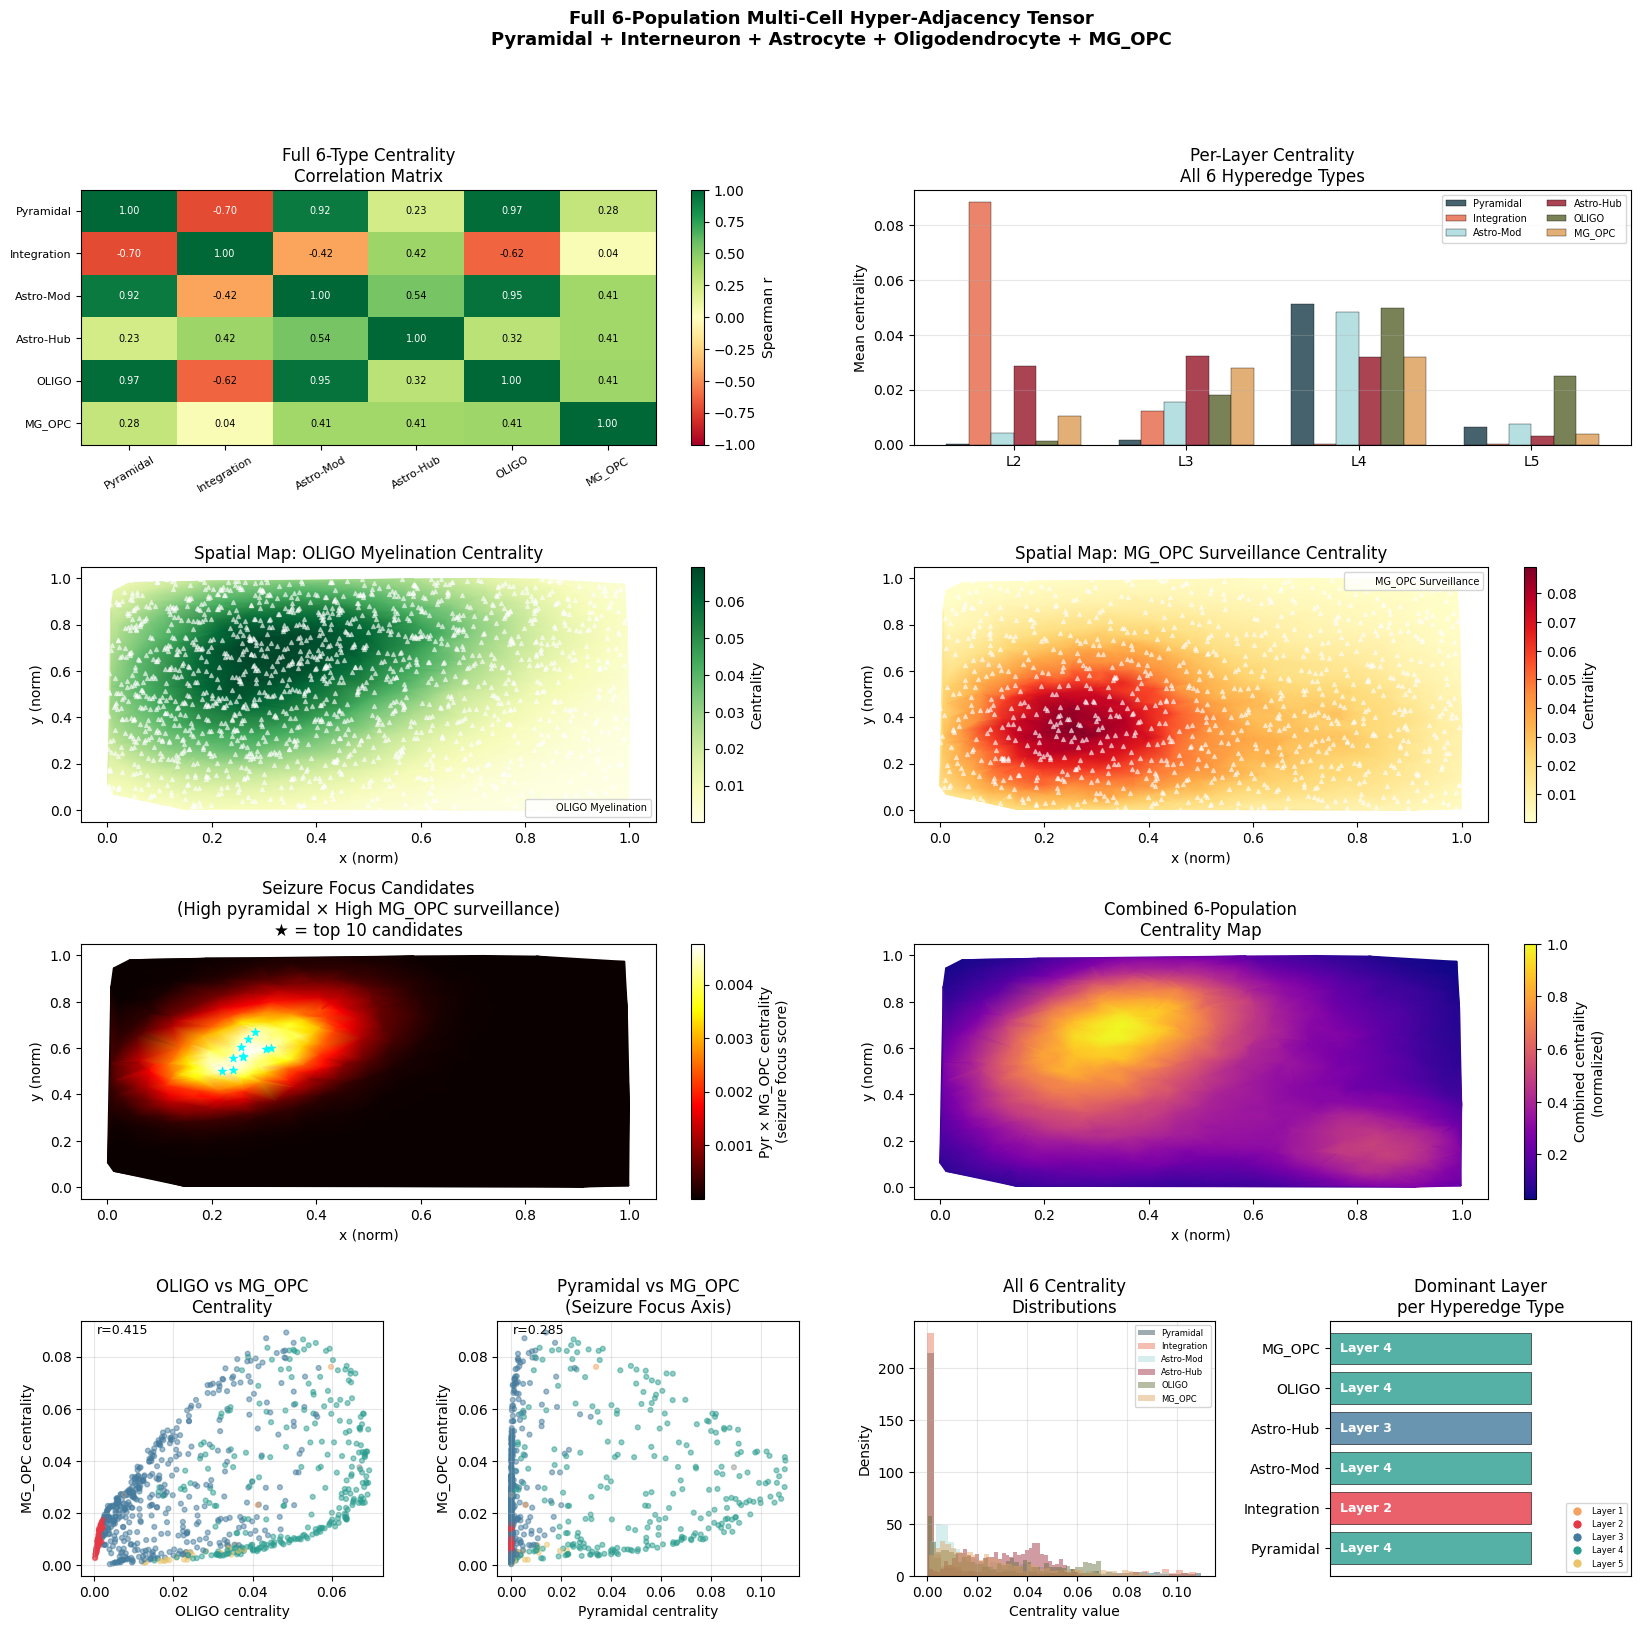

Saved: full_6population_tensor.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# FULL 6-POPULATION TENSOR VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.tri import Triangulation
from matplotlib.lines import Line2D
import numpy as np

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(4, 4, figure=fig,
                         hspace=0.48, wspace=0.38)

layer_colors_map = {
    'Layer 1':'#F4A261','Layer 2':'#E63946',
    'Layer 3':'#457B9D','Layer 4':'#2A9D8F',
    'Layer 5':'#E9C46A','White matter':'#6D6875',
    'unclassified':'#999999'
}
node_colors = [layer_colors_map.get(l,'#999') for l in layer_labels]
triang      = Triangulation(coords_norm[:,0],
                             coords_norm[:,1], triangles)

type_colors_6 = {
    'Pyramidal':   '#264653',
    'Integration': '#E76F51',
    'Astro-Mod':   '#A8DADC',
    'Astro-Hub':   '#9B2335',
    'OLIGO':       '#606C38',
    'MG_OPC':      '#DDA15E'
}

# ── Plot 1: Full 6x6 correlation heatmap ─────────────────────
ax1 = fig.add_subplot(gs[0, :2])
corr_6 = np.zeros((6, 6))
for i, n1 in enumerate(names_all):
    for j, n2 in enumerate(names_all):
        v1, v2 = cent_all[n1], cent_all[n2]
        if v1.std() < 1e-10 or v2.std() < 1e-10:
            corr_6[i,j] = 0
        else:
            r, _ = spearmanr(v1, v2)
            corr_6[i,j] = r
im1 = ax1.imshow(corr_6, cmap='RdYlGn',
                  vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im1, ax=ax1, label='Spearman r')
ax1.set_xticks(range(6))
ax1.set_yticks(range(6))
ax1.set_xticklabels(names_all, fontsize=8, rotation=30)
ax1.set_yticklabels(names_all, fontsize=8)
ax1.set_title('Full 6-Type Centrality\nCorrelation Matrix')
for i in range(6):
    for j in range(6):
        ax1.text(j, i, f'{corr_6[i,j]:.2f}',
                 ha='center', va='center', fontsize=7,
                 color='black' if abs(corr_6[i,j]) < 0.7
                 else 'white')

# ── Plot 2: Per-layer centrality all 6 types ─────────────────
ax2 = fig.add_subplot(gs[0, 2:])
layers_plot = ['Layer 2','Layer 3','Layer 4','Layer 5']
x_pos = np.arange(len(layers_plot))
width = 0.13
for ki, (name, color) in enumerate(type_colors_6.items()):
    means = [cent_all[name][layer_labels==l].mean()
             if (layer_labels==l).sum()>0 else 0
             for l in layers_plot]
    offset = (ki - 2.5) * width
    ax2.bar(x_pos + offset, means, width,
            label=name, color=color,
            alpha=0.85, edgecolor='black', linewidth=0.3)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([l.replace('Layer ','L')
                      for l in layers_plot])
ax2.set_ylabel('Mean centrality')
ax2.set_title('Per-Layer Centrality\nAll 6 Hyperedge Types')
ax2.legend(fontsize=7, ncol=2); ax2.grid(alpha=0.3, axis='y')

# ── Plots 3-4: OLIGO and MG_OPC spatial maps ─────────────────
for plot_idx, (cent, name, df_cell, cmap) in enumerate([
        (cent_oligo, 'OLIGO Myelination',   oligo_df, 'YlGn'),
        (cent_mgopc, 'MG_OPC Surveillance', mgopc_df, 'YlOrRd')]):
    ax = fig.add_subplot(gs[1, plot_idx*2:plot_idx*2+2])
    sc = ax.tripcolor(triang, cent, cmap=cmap,
                      shading='gouraud')
    plt.colorbar(sc, ax=ax, label='Centrality')
    # Overlay cell positions
    cx = ((df_cell['x'].values - coords[:,0].min()) /
          (coords[:,0].max() - coords[:,0].min()))
    cy = ((df_cell['y'].values - coords[:,1].min()) /
          (coords[:,1].max() - coords[:,1].min()))
    in_b = ((cx>=0)&(cx<=1)&(cy>=0)&(cy<=1))
    ax.scatter(cx[in_b], cy[in_b], c='white',
               s=8, alpha=0.5, marker='^',
               label=name, zorder=5)
    ax.set_title(f'Spatial Map: {name} Centrality')
    ax.set_xlabel('x (norm)'); ax.set_ylabel('y (norm)')
    ax.legend(fontsize=7)

# ── Plot 5: Seizure focus candidate map ──────────────────────
ax5 = fig.add_subplot(gs[2, :2])
sc5 = ax5.tripcolor(triang, combined_score,
                    cmap='hot', shading='gouraud')
plt.colorbar(sc5, ax=ax5,
             label='Pyr × MG_OPC centrality\n(seizure focus score)')
# Mark top 10 candidates
for ti in top_seizure:
    ax5.scatter(coords_norm[ti,0], coords_norm[ti,1],
                c='cyan', s=40, marker='*',
                zorder=6, linewidths=0.5)
ax5.set_title('Seizure Focus Candidates\n'
              '(High pyramidal × High MG_OPC surveillance)\n'
              '★ = top 10 candidates')
ax5.set_xlabel('x (norm)'); ax5.set_ylabel('y (norm)')

# ── Plot 6: Combined 6-population centrality map ─────────────
ax6 = fig.add_subplot(gs[2, 2:])
sc6 = ax6.tripcolor(triang, combined_6pop,
                    cmap='plasma', shading='gouraud')
plt.colorbar(sc6, ax=ax6, label='Combined centrality\n(normalized)')
ax6.set_title('Combined 6-Population\nCentrality Map')
ax6.set_xlabel('x (norm)'); ax6.set_ylabel('y (norm)')

# ── Plot 7: OLIGO vs MG_OPC centrality scatter ───────────────
ax7 = fig.add_subplot(gs[3, 0])
ax7.scatter(cent_oligo, cent_mgopc,
            c=node_colors, alpha=0.5, s=12)
ax7.set_xlabel('OLIGO centrality')
ax7.set_ylabel('MG_OPC centrality')
ax7.set_title('OLIGO vs MG_OPC\nCentrality')
ax7.grid(alpha=0.3)
r_om, _ = spearmanr(cent_oligo, cent_mgopc)
ax7.text(0.05, 0.95, f'r={r_om:.3f}',
         transform=ax7.transAxes, fontsize=9)

# ── Plot 8: Pyramidal vs MG_OPC (seizure axis) ───────────────
ax8 = fig.add_subplot(gs[3, 1])
ax8.scatter(cent_pyr, cent_mgopc,
            c=node_colors, alpha=0.5, s=12)
ax8.set_xlabel('Pyramidal centrality')
ax8.set_ylabel('MG_OPC centrality')
ax8.set_title('Pyramidal vs MG_OPC\n(Seizure Focus Axis)')
ax8.grid(alpha=0.3)
r_pm, _ = spearmanr(cent_pyr, cent_mgopc)
ax8.text(0.05, 0.95, f'r={r_pm:.3f}',
         transform=ax8.transAxes, fontsize=9)

# ── Plot 9: Centrality distributions all 6 ───────────────────
ax9 = fig.add_subplot(gs[3, 2])
for name, color in type_colors_6.items():
    ax9.hist(cent_all[name], bins=40, alpha=0.45,
             color=color, label=name, density=True)
ax9.set_xlabel('Centrality value')
ax9.set_ylabel('Density')
ax9.set_title('All 6 Centrality\nDistributions')
ax9.legend(fontsize=6); ax9.grid(alpha=0.3)

# ── Plot 10: Layer dominance per type (radar-style bar) ───────
ax10 = fig.add_subplot(gs[3, 3])
dominant_layers = []
for name in names_all:
    layer_means = {l: cent_all[name][layer_labels==l].mean()
                   for l in layers_plot
                   if (layer_labels==l).sum()>0}
    dominant_layers.append(
        max(layer_means, key=layer_means.get))

dom_colors = [layer_colors_map.get(l,'#999')
              for l in dominant_layers]
ax10.barh(names_all, [1]*6, color=dom_colors,
          alpha=0.8, edgecolor='black', linewidth=0.5)
ax10.set_xlabel('')
ax10.set_title('Dominant Layer\nper Hyperedge Type')
ax10.set_xlim(0, 1.5)
for i, l in enumerate(dominant_layers):
    ax10.text(0.05, i, l, va='center',
              fontsize=9, fontweight='bold', color='white')
ax10.set_xticks([])

legend_els = [Line2D([0],[0], marker='o', color='w',
              markerfacecolor=c, markersize=7, label=l)
              for l, c in layer_colors_map.items()
              if (layer_labels==l).sum() > 0]
ax10.legend(handles=legend_els, fontsize=6,
            loc='lower right')

plt.suptitle('Full 6-Population Multi-Cell Hyper-Adjacency Tensor\n'
             'Pyramidal + Interneuron + Astrocyte + '
             'Oligodendrocyte + MG_OPC',
             fontsize=13, fontweight='bold')
plt.savefig('full_6population_tensor.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: full_6population_tensor.png")

**Checkpoint:** run the cell below after finishing this notebook so `06_Incremental_Spatial_Expansion` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/05_state.pkl")
print("Saved checkpoint: checkpoints/05_state.pkl")